## Задание №1

In [1]:
Tz_test = [0, 0.12, 1.291, 6.594, 6.821, 9.031, 14.971, 17.15]
Ts_test = [0, 0.634, 2.31, 6.78, 0.477, 5.104, 0.459, 1.442]
Tmod = 17

## Задание №2

In [2]:
import numpy as np

def model(Tz, Ts, Tmod):
    """
    Tz — моменты поступления заявок
    Ts — времена обслуживания
    Tmod — время моделирования
    """

    busy_until = 0          # момент освобождения процессора
    processed = 0
    refused = 0

    busy_time = 0
    idle_time = 0

    last_event_time = 0

    for i in range(1, len(Tz)):
        arrival = Tz[i]
        service = Ts[i]

        if arrival > Tmod:
            break

        # если процессор свободен
        if arrival >= busy_until:
            # добавляем простой
            idle_time += arrival - max(last_event_time, busy_until)

            start = arrival
            end = start + service

            busy_time += service
            busy_until = end

            processed += 1
            last_event_time = end

        else:
            refused += 1

    total_arrived = processed + refused
    total_time = max(busy_until, Tz[-1])

    relative_throughput = processed / total_arrived if total_arrived > 0 else 0
    cpu_load = busy_time / total_time if total_time > 0 else 0
    cpu_idle_prob = idle_time / total_time if total_time > 0 else 0

    return (
        processed,
        refused,
        total_arrived,
        round(relative_throughput, 3),
        round(busy_time, 3),
        round(idle_time, 3),
        round(total_time, 3),
        round(cpu_load, 3),
        round(cpu_idle_prob, 3)
    )

## Задание №3

In [3]:
Tz_test = [0, 0.12, 1.291, 6.594, 6.821, 9.031, 14.971, 17.15]
Ts_test = [0, 0.634, 2.31, 6.78, 0.477, 5.104, 0.459, 1.442]
Tmod = 17

result = model(Tz_test, Ts_test, Tmod)

result

(4, 2, 6, 0.667, 10.183, 5.247, 17.15, 0.594, 0.306)

## Задание №4

In [4]:
def generate_stream(lmbda, mu, Tmod):
    Tz = [0]
    Ts = [0]

    current_time = 0

    while current_time < Tmod:
        interarrival = np.random.exponential(1/lmbda)
        current_time += interarrival
        Tz.append(current_time)

        service_time = np.random.exponential(1/mu)
        Ts.append(service_time)

    return Tz, Ts

In [5]:
def run_experiment(lmbda, mu, Tmod=10000):
    Tz, Ts = generate_stream(lmbda, mu, Tmod)
    res = model(Tz, Ts, Tmod)
    
    Q_sim = res[3]      # относительная пропускная способность
    load_sim = res[7]   # загрузка процессора
    
    return Q_sim, load_sim

In [6]:
import matplotlib.pyplot as plt

mu = 1
rho_values = np.linspace(0.01, 1, 20)

Q_sim_list = []
load_sim_list = []
Q_theory = []
load_theory = []

for rho in rho_values:
    lmbda = rho * mu
    
    Q_sim, load_sim = run_experiment(lmbda, mu)
    
    Q_sim_list.append(Q_sim)
    load_sim_list.append(load_sim)
    
    Q_theory.append(1/(1+rho))
    load_theory.append(rho/(1+rho))

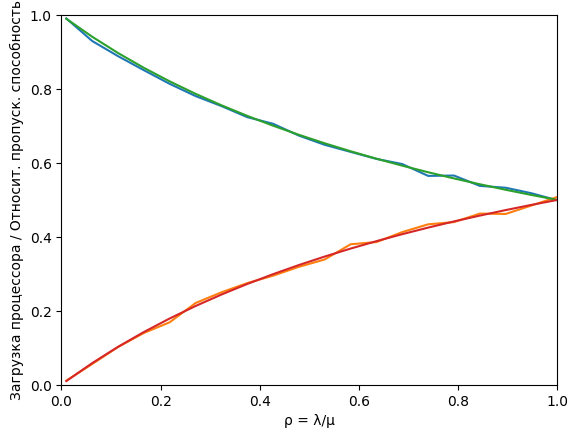

In [7]:
plt.figure()
plt.plot(rho_values, Q_sim_list)
plt.plot(rho_values, load_sim_list)
plt.plot(rho_values, Q_theory)
plt.plot(rho_values, load_theory)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("ρ = λ/μ")
plt.ylabel("Загрузка процессора / Относит. пропуск. способность")
plt.show()

In [14]:
import pandas as pd
import numpy as np

mu = 1
rho_values = np.linspace(0.01, 1, 20)

results = []

for rho in rho_values:
    lmbda = rho * mu
    
    Q_sim, load_sim = run_experiment(lmbda, mu)
    
    Q_theory = 1 / (1 + rho)
    load_theory = rho / (1 + rho)
    
    results.append([rho, Q_sim, Q_theory, load_sim, load_theory])

# создаём DataFrame
df = pd.DataFrame(results, columns=[
    "p",
    "Q_sim",
    "Q_theory",
    "k_sim",
    "k_theory"
])

# вычисляем математические ожидания (средние)
mean_row = pd.DataFrame([[
    "Mean",
    df["Q_sim"].mean(),
    df["Q_theory"].mean(),
    df["k_sim"].mean(),
    df["k_theory"].mean()
]], columns=df.columns)

# объединяем таблицу и строку среднего
df_final = pd.concat([df, mean_row], ignore_index=True)

df_final

,p,Q_sim,Q_theory,k_sim,k_theory
0,0.01,0.979167,0.990099,0.009783,0.009901
1,0.062105,0.958974,0.941526,0.057742,0.058474
2,0.114211,0.896014,0.897496,0.098292,0.102504
3,0.166316,0.855335,0.857401,0.142222,0.142599
4,0.218421,0.809783,0.820734,0.183497,0.179266
5,0.270526,0.788362,0.787075,0.215763,0.212925
6,0.322632,0.747661,0.756068,0.249572,0.243932
7,0.374737,0.736770,0.727412,0.271224,0.272588
8,0.426842,0.706398,0.700848,0.298237,0.299152
9,0.478947,0.678398,0.676157,0.332948,0.323843
